# 07. FT-Transformer (supervised, бинарная классификация)

**Цель:** применение современной attention-based архитектуры к табличной задаче обнаружения аномалий.

**Зачем трансформер на табличных данных:** несмотря на отсутствие
временной структуры (временных рпядов), attention-механизм применим к взаимодействиям между признаками: модель учится решать - насколько важен признак X в
контексте значения признака Y. 
   - Reference: Gorishniy et al. (2021), «Revisiting Deep Learning Models for Tabular Data».


**Замечания:**
1. Демонстрация применимости трансформерных архитектур к IDS-задаче.
2. Attention-карты — механизм интерпретируемости
   (в дополнение к feature_importance из RF/XGBoost).
3. Прирост по F1 не ожидается — уже достигнут потолок задачи (XGBoost = 0.9988,
   MLP = 0.99848). Цель — показать, что FT-Transformer **не хуже**.

**Архитектура моедли:** `TabularFTTransformer` в `models/architectures.py`:
- d_token = 32, n_blocks = 2, n_heads = 4
- ffn_hidden = 128 (4x d_token), GELU activation
- attn_dropout = 0.2, ffn_dropout = 0.1
- Pre-LayerNorm, CLS-token для агрегации
- ~50-80k параметров

- AdamW(lr=5e-4, wd=1e-5), CosineAnnealing с 2-эпохным
warmup, max 20 эпох + early stop по val F1 (patience=5),
BCEWithLogitsLoss(pos_weight=3.23), batch=4096.

In [ ]:
from __future__ import annotations

import json
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR

CACHE_DIR = PROJECT_ROOT / "cache"
ARTIFACTS = PROJECT_ROOT / "artifacts"
FIG_DIR   = PROJECT_ROOT / "results" / "figures"
TAB_DIR   = PROJECT_ROOT / "results" / "tables"
for p in (FIG_DIR, TAB_DIR):
    p.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.metrics import compute_binary_metrics, confusion_matrix_dict
from models.architectures import TabularFTTransformer               

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__}, device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch: 2.11.0a0+a6c236b9fd.nv26.03.46836102, device: cuda
GPU: NVIDIA GeForce RTX 5080


In [2]:
X_train_full = pd.read_parquet(CACHE_DIR / "X_train.parquet")
X_test       = pd.read_parquet(CACHE_DIR / "X_test.parquet")
y_train_full = pd.read_parquet(CACHE_DIR / "y_train.parquet")["target"].values
y_test       = pd.read_parquet(CACHE_DIR / "y_test.parquet" )["target"].values

with (ARTIFACTS / "preprocessing_config.json").open() as f:
    pp_config = json.load(f)
MODEL_FEATURES = pp_config["model_features"]
assert list(X_train_full.columns) == MODEL_FEATURES

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full.values.astype(np.float32),
    y_train_full.astype(np.float32),
    test_size=0.10,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)
X_test_np = X_test.values.astype(np.float32)
y_test_f  = y_test.astype(np.float32)

n_anomaly = float(y_train.sum())
n_benign  = float(len(y_train) - n_anomaly)
pos_weight_value = n_benign / n_anomaly
print(f"X_train: {X_train.shape}, anomaly={y_train.mean()*100:.2f}%")
print(f"X_val:   {X_val.shape}, anomaly={y_val.mean()*100:.2f}%")
print(f"pos_weight = {pos_weight_value:.4f}")

X_train: (1330011, 42), anomaly=23.63%
X_val:   (147780, 42), anomaly=23.63%
pos_weight = 3.2319


In [ ]:
ft_config = {
    "n_features":   42,
    "d_token":      32,
    "n_blocks":     2,
    "n_heads":      4,
    "ffn_hidden":   128,
    "attn_dropout": 0.2,
    "ffn_dropout":  0.1,
}
training_config = {
    "batch_size":          4096,
    "max_epochs":          20,
    "lr":                  5e-4,
    "weight_decay":        1e-5,
    "warmup_epochs":       2,
    "early_stop_patience": 5,
    "early_stop_metric":   "val_f1_anomaly",
    "pos_weight":          pos_weight_value,
    "decision_threshold":  0.5,
}

model = TabularFTTransformer(**ft_config).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nПараметров: {n_params:,}")
print(f"MLP параметров (для сравнения): 14,657"
      f"FT-Transformer / MLP = {n_params / 14_657:.1f}×")

TabularFTTransformer(
  (tokenizer): _FeatureTokenizer()
  (cls): _CLSToken()
  (blocks): ModuleList(
    (0-1): 2 x _TransformerBlock(
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
      )
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=32, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=32, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)

Параметров: 28,225
MLP параметров (для сравнения): 14,657 → FT-Transformer / MLP = 1.9×


In [4]:
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float().unsqueeze(1)
X_val_t   = torch.from_numpy(X_val).float()
y_val_t   = torch.from_numpy(y_val).float().unsqueeze(1)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=training_config["batch_size"],
    shuffle=True, num_workers=0, pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=training_config["batch_size"],
    shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"),
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=training_config["lr"],
    weight_decay=training_config["weight_decay"],
)

# Кастомный scheduler: linear warmup + cosine
warmup_epochs = training_config["warmup_epochs"]
max_epochs = training_config["max_epochs"]

def lr_lambda(epoch: int) -> float:
    if epoch < warmup_epochs:
        # linear от 0 до 1
        return (epoch + 1) / warmup_epochs
    # cosine от 1 до 0 на оставшиеся эпохи
    progress = (epoch - warmup_epochs) / max(1, max_epochs - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

pos_weight_tensor = torch.tensor([pos_weight_value], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
print(f"Optimizer: AdamW(lr={training_config['lr']}, "
      f"wd={training_config['weight_decay']})")
print(f"Scheduler: linear warmup ({warmup_epochs} epochs) → "
      f"cosine over {max_epochs - warmup_epochs} epochs")

Optimizer: AdamW(lr=0.0005, wd=1e-05)
Scheduler: linear warmup (2 epochs) → cosine over 18 epochs


In [5]:
@torch.no_grad()
def evaluate_model(model, loader, threshold: float = 0.5):
    model.eval()
    losses, all_y, all_score = [], [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        losses.append(loss.item() * x.size(0))
        proba = torch.sigmoid(logits).cpu().numpy().ravel()
        all_y.append(y.cpu().numpy().ravel())
        all_score.append(proba)
    n = sum(len(a) for a in all_y)
    avg_loss = sum(losses) / n
    y_true_np  = np.concatenate(all_y).astype(np.int64)
    y_score_np = np.concatenate(all_score)
    y_pred_np  = (y_score_np >= threshold).astype(np.int64)
    m = compute_binary_metrics(y_true_np, y_pred_np, y_score=y_score_np)
    return avg_loss, m["f1_anomaly"], m["accuracy"], y_true_np, y_score_np, y_pred_np

In [6]:
history = {"epoch": [], "train_loss": [], "val_loss": [],
           "val_f1": [], "val_acc": [], "lr": [], "epoch_time": []}
best_val_f1 = -1.0
best_state  = None
patience_counter = 0

t_total = time.time()
for epoch in range(1, training_config["max_epochs"] + 1):
    t_epoch = time.time()
    model.train()
    train_loss_sum, n_samples = 0.0, 0
    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        # Gradient clipping — стандарт для трансформеров
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss_sum += loss.item() * x.size(0)
        n_samples += x.size(0)
    train_loss = train_loss_sum / n_samples

    val_loss, val_f1, val_acc, _, _, _ = evaluate_model(model, val_loader, 0.5)
    scheduler.step()
    cur_lr = optimizer.param_groups[0]["lr"]
    epoch_time = time.time() - t_epoch

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["val_acc"].append(val_acc)
    history["lr"].append(cur_lr)
    history["epoch_time"].append(epoch_time)

    improved = val_f1 > best_val_f1 + 1e-6
    flag = " ← best" if improved else ""
    print(f"epoch {epoch:>2d}  "
          f"train_loss={train_loss:.5f}  val_loss={val_loss:.5f}  "
          f"val_F1={val_f1:.5f}  val_acc={val_acc:.5f}  "
          f"lr={cur_lr:.5f}  t={epoch_time:.1f}s{flag}")

    if improved:
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= training_config["early_stop_patience"]:
            print(f"\nEarly stop на эпохе {epoch} (patience {patience_counter})")
            break

total_train_time = time.time() - t_total
print(f"\nОбщее время обучения: {total_train_time:.1f} сек "
      f"({total_train_time/60:.1f} мин)")
print(f"Best val F1_anomaly: {best_val_f1:.5f}")

model.load_state_dict(best_state)
model.eval()

epoch  1  train_loss=0.13719  val_loss=0.04491  val_F1=0.98895  val_acc=0.99478  lr=0.00050  t=12.3s ← best
epoch  2  train_loss=0.03438  val_loss=0.01889  val_F1=0.99382  val_acc=0.99707  lr=0.00050  t=12.1s ← best
epoch  3  train_loss=0.01559  val_loss=0.01067  val_F1=0.99765  val_acc=0.99889  lr=0.00050  t=12.0s ← best
epoch  4  train_loss=0.01121  val_loss=0.00915  val_F1=0.99784  val_acc=0.99898  lr=0.00048  t=12.0s ← best
epoch  5  train_loss=0.00960  val_loss=0.00805  val_F1=0.99800  val_acc=0.99905  lr=0.00047  t=11.9s ← best
epoch  6  train_loss=0.00846  val_loss=0.00691  val_F1=0.99813  val_acc=0.99911  lr=0.00044  t=11.9s ← best
epoch  7  train_loss=0.00799  val_loss=0.00766  val_F1=0.99754  val_acc=0.99884  lr=0.00041  t=11.9s
epoch  8  train_loss=0.00746  val_loss=0.00631  val_F1=0.99811  val_acc=0.99911  lr=0.00038  t=11.9s
epoch  9  train_loss=0.00705  val_loss=0.00596  val_F1=0.99817  val_acc=0.99913  lr=0.00034  t=11.9s ← best
epoch 10  train_loss=0.00664  val_loss=0.0

TabularFTTransformer(
  (tokenizer): _FeatureTokenizer()
  (cls): _CLSToken()
  (blocks): ModuleList(
    (0-1): 2 x _TransformerBlock(
      (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
      )
      (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=32, out_features=128, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=32, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)

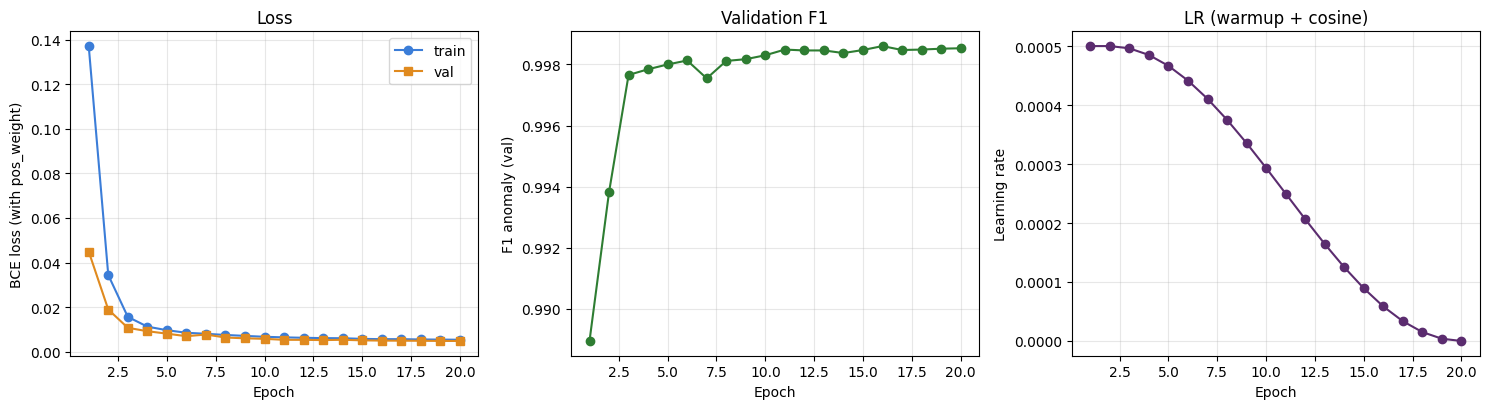

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(history["epoch"], history["train_loss"], "o-",
             label="train", color="#3B7DD8", lw=1.5)
axes[0].plot(history["epoch"], history["val_loss"], "s-",
             label="val",   color="#E08A1F", lw=1.5)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss (with pos_weight)")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["val_f1"], "o-", color="#2E7D32", lw=1.5)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1 anomaly (val)")
axes[1].set_title("Validation F1"); axes[1].grid(alpha=0.3)

axes[2].plot(history["epoch"], history["lr"], "o-", color="#5B2C6F", lw=1.5)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning rate")
axes[2].set_title("LR (warmup + cosine)"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_08_ft_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
y_test_t = torch.from_numpy(y_test_f).float().unsqueeze(1)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_np).float(), y_test_t),
    batch_size=training_config["batch_size"],
    shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"),
)

t0 = time.time()
_, _, _, _, y_score_test, y_pred_test = evaluate_model(
    model, test_loader, training_config["decision_threshold"]
)
predict_time = time.time() - t0

# Train метрики
X_train_full_t = torch.from_numpy(X_train_full.values.astype(np.float32)).float()
y_train_full_t = torch.from_numpy(y_train_full.astype(np.float32)).float().unsqueeze(1)
train_loader_full = DataLoader(
    TensorDataset(X_train_full_t, y_train_full_t),
    batch_size=training_config["batch_size"],
    shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"),
)
_, _, _, _, y_score_train, y_pred_train = evaluate_model(
    model, train_loader_full, training_config["decision_threshold"]
)

metrics_test  = compute_binary_metrics(y_test, y_pred_test, y_score=y_score_test)
metrics_train = compute_binary_metrics(y_train_full, y_pred_train, y_score=y_score_train)
cm_test  = confusion_matrix_dict(y_test, y_pred_test)
cm_train = confusion_matrix_dict(y_train_full, y_pred_train)

print(f"Predict time на test: {predict_time:.2f} сек "
      f"({len(y_test) / predict_time:,.0f} flow/sec)")
print(f"\nConfusion matrix (test): {cm_test}")
print("\nMetrics:")
print(pd.DataFrame({"train": metrics_train, "test": metrics_test}).round(5).to_string())
print(f"\nF1 overfit gap: "
      f"{metrics_train['f1_anomaly'] - metrics_test['f1_anomaly']:+.5f}")

Predict time на test: 3.04 сек (208,433 flow/sec)

Confusion matrix (test): {'tn': 483274, 'fp': 407, 'fn': 34, 'tp': 149625}

Metrics:
                     train     test
accuracy           0.99930  0.99930
precision_anomaly  0.99733  0.99729
recall_anomaly     0.99972  0.99977
f1_anomaly         0.99852  0.99853
precision_benign   0.99991  0.99993
recall_benign      0.99917  0.99916
f1_benign          0.99954  0.99954
f1_macro           0.99903  0.99904
f1_weighted        0.99930  0.99930
balanced_accuracy  0.99944  0.99947
roc_auc            0.99992  0.99992
pr_auc             0.99953  0.99952

F1 overfit gap: -0.00000


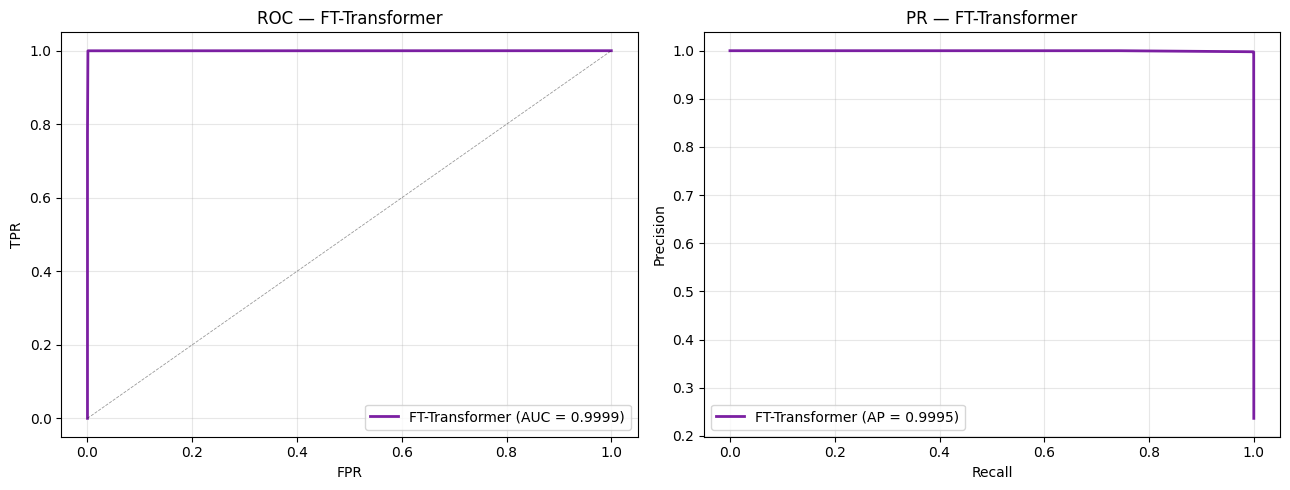

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, y_score_test)
axes[0].plot(fpr, tpr, color="#7B1FA2", lw=2,
             label=f"FT-Transformer (AUC = {metrics_test['roc_auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.6, alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC — FT-Transformer")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, y_score_test)
axes[1].plot(rec, prec, color="#7B1FA2", lw=2,
             label=f"FT-Transformer (AP = {metrics_test['pr_auc']:.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR — FT-Transformer")
axes[1].legend(loc="lower left"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_08_ft_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

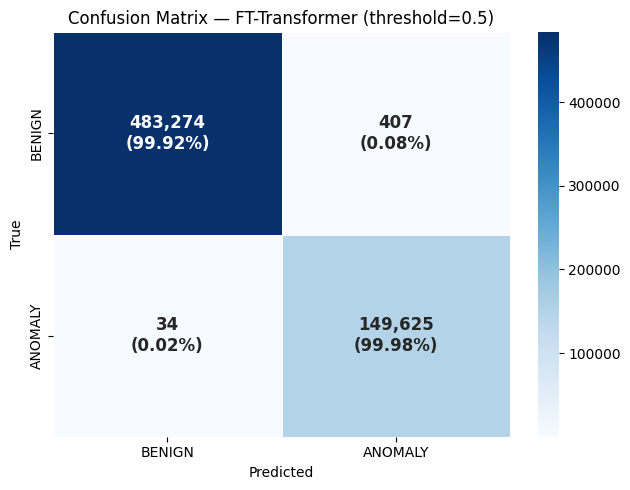

In [10]:
cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f"{cm[i,j]:,}\n({cm_pct[i,j]:.2f}%)" for j in range(2)]
                  for i in range(2)], dtype=object)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(
    cm, annot=annot, fmt="", cmap="Blues",
    xticklabels=["BENIGN", "ANOMALY"],
    yticklabels=["BENIGN", "ANOMALY"],
    cbar=True, linewidths=0.5, linecolor="white",
    annot_kws={"size": 12, "weight": "bold"},
    ax=ax,
)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — FT-Transformer (threshold=0.5)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_08_ft_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Attention map analysis — уникальная ценность FT-Transformer

Attention-карта показывает, насколько каждый признак "обращает внимание"
на каждый другой при принятии решения. Мы визуализируем:
1. Attention CLS-токена на 42 фичи — это что модель смотрит для принятия итогового решения.
2. Pair-wise attention между фичами в последнем блоке — это как фичи взаимодействуют.

In [ ]:
# Береться батч из test для извлечения attention
sample_x = torch.from_numpy(X_test_np[:1024]).float().to(device)
with torch.no_grad():
    attn_maps = model.get_attention_maps(sample_x)

# attn_maps — список с n_blocks тензоров формы (B, seq_len, seq_len),
# где seq_len = n_features + 1 (CLS первый).
# Усреднение по батчу.
print(f"Attention maps: {len(attn_maps)} блоков, "
      f"shape каждого: {attn_maps[0].shape}")

# Берется последний блок (он принимает финальное решение)
last_attn = attn_maps[-1].mean(dim=0).cpu().numpy()  # (43, 43)

# (1) Attention CLS на 42 фичи — что модель смотрит для решения
cls_attention = last_attn[0, 1:]   # первая строка (CLS), без самого CLS
feature_attn = pd.DataFrame({
    "feature":   MODEL_FEATURES,
    "cls_attn":  cls_attention,
}).sort_values("cls_attn", ascending=False)
feature_attn.to_csv(TAB_DIR / "ft_cls_attention.csv", index=False)
print("\nТоп-15 признаков по attention от CLS-токена:")
print(feature_attn.head(15).to_string(index=False))

Attention maps: 2 блоков, shape каждого: torch.Size([1024, 43, 43])

Топ-15 признаков по attention от CLS-токена:
                   feature  cls_attn
       src2dst_psh_packets  0.048010
     bidirectional_mean_ps  0.045435
 bidirectional_psh_packets  0.034032
       dst2src_psh_packets  0.033600
           dst2src_packets  0.031242
             src2dst_bytes  0.030101
 bidirectional_duration_ms  0.029564
      bidirectional_min_ps  0.029132
           dst2src_mean_ps  0.028545
 bidirectional_ack_packets  0.026444
             dst2src_bytes  0.025847
            dst2src_max_ps  0.025239
            src2dst_max_ps  0.025013
bidirectional_mean_piat_ms  0.024837
       src2dst_urg_packets  0.024508


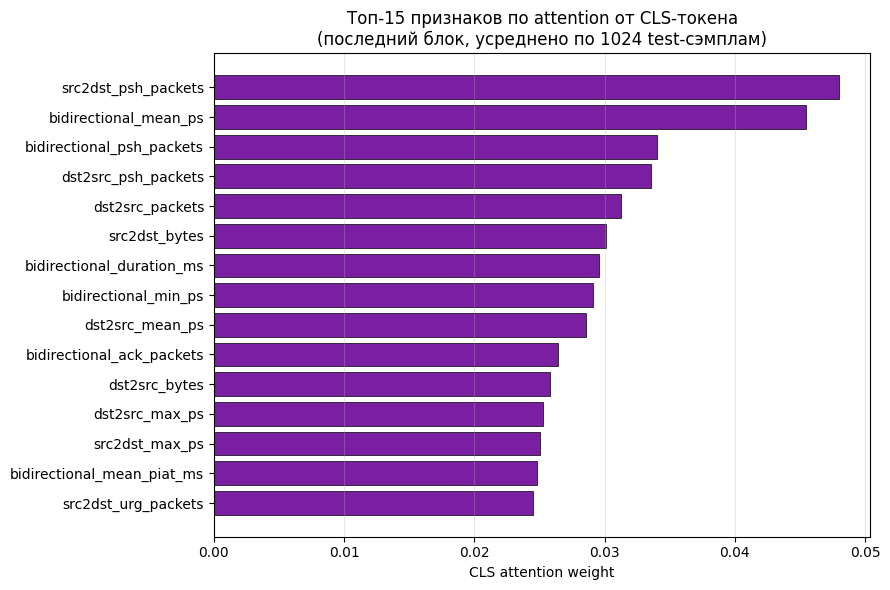

In [12]:
top15 = feature_attn.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15["feature"], top15["cls_attn"],
        color="#7B1FA2", edgecolor="black", linewidth=0.5)
ax.set_xlabel("CLS attention weight")
ax.set_title("Топ-15 признаков по attention от CLS-токена\n"
             "(последний блок, усреднено по 1024 test-сэмплам)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_08_ft_cls_attention.png",
            dpi=150, bbox_inches="tight")
plt.show()

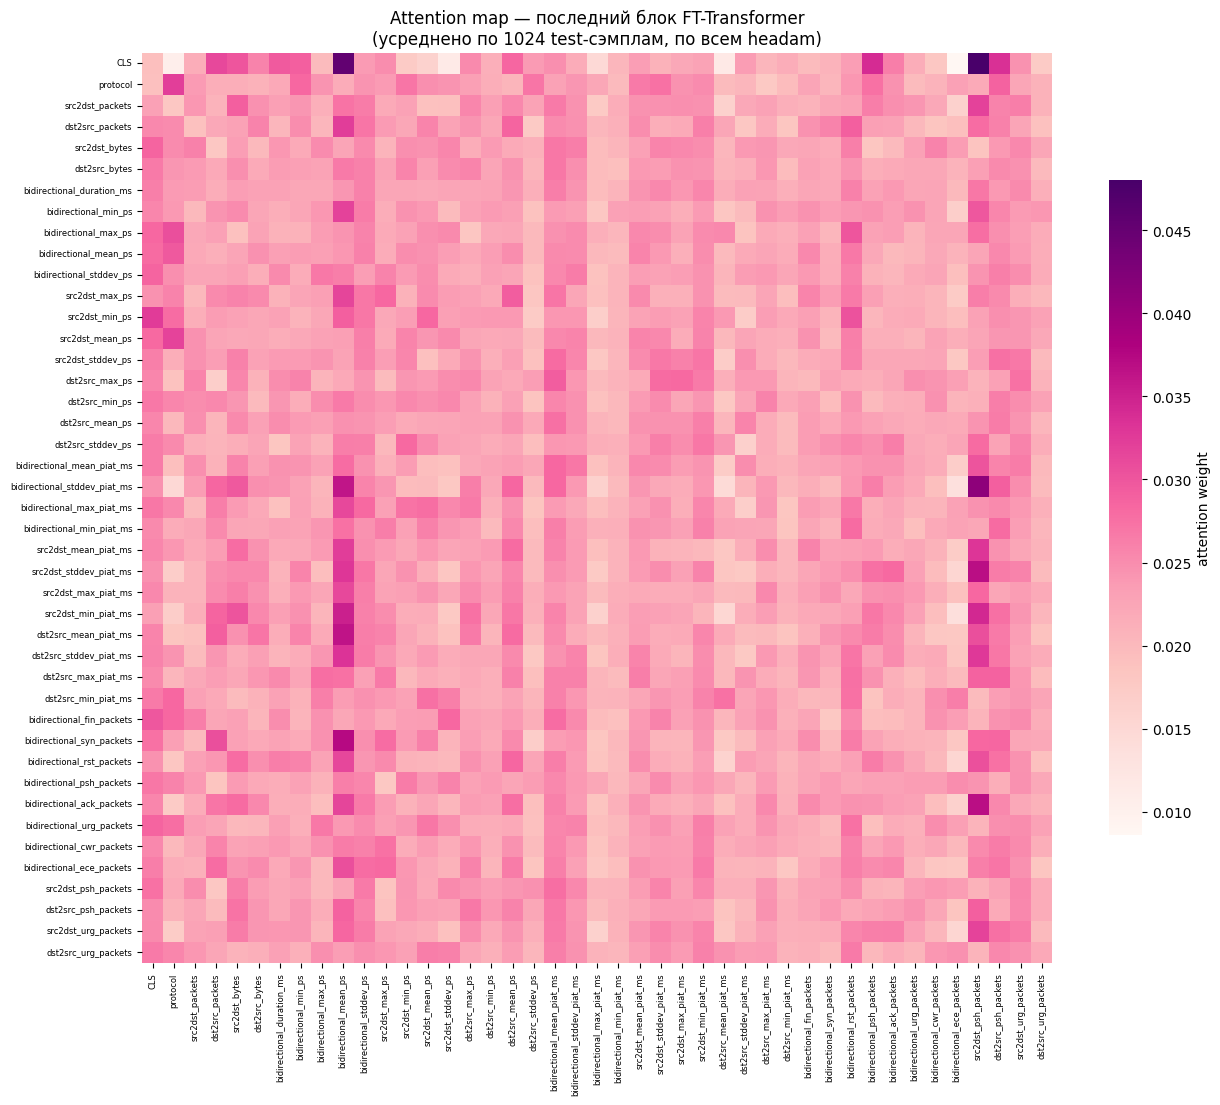

In [13]:
# Полная attention матрица 43x43 (CLS + 42 фичи)
labels = ["CLS"] + MODEL_FEATURES

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    last_attn, cmap="RdPu",
    xticklabels=labels, yticklabels=labels,
    square=True, cbar_kws={"shrink": 0.7, "label": "attention weight"},
    ax=ax,
)
ax.set_title("Attention map — последний блок FT-Transformer\n"
             "(усреднено по 1024 test-сэмплам, по всем headam)",
             fontsize=12)
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_08_ft_attention_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

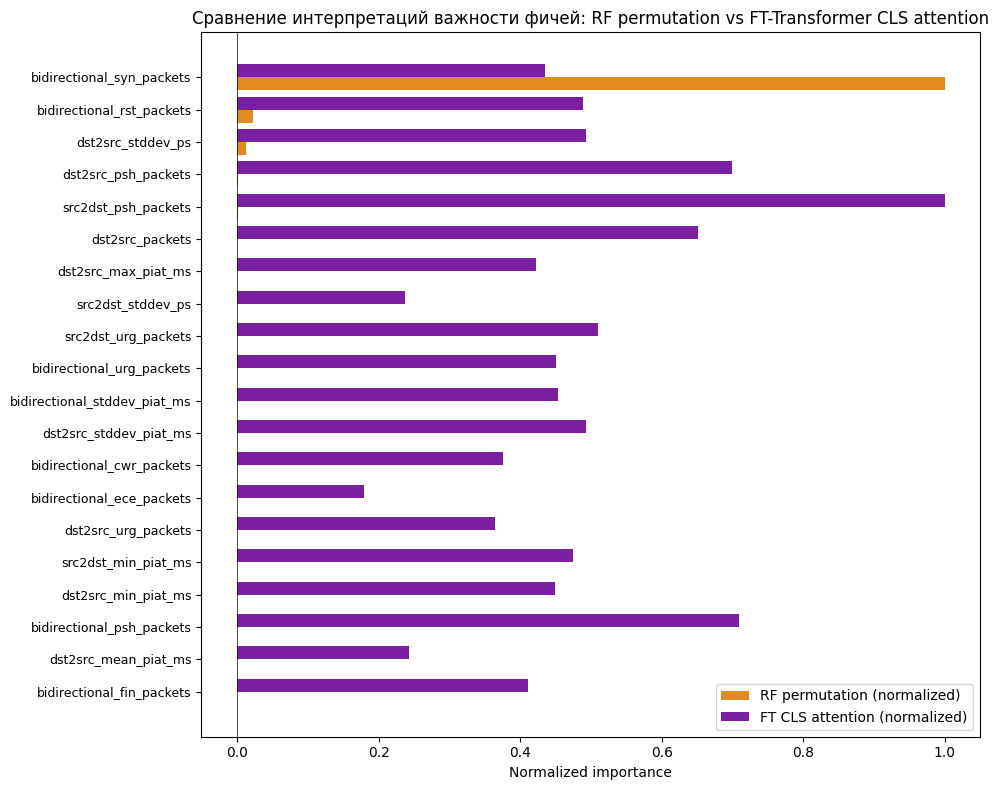

In [14]:
# Сравнение: какие фичи RF (по permutation) и FT-Transformer (по CLS attention)
# считают важными. Это две независимые интерпретации.
rf_imp = pd.read_csv(TAB_DIR / "rf_feature_importance.csv")
merged = rf_imp.merge(feature_attn, on="feature")
merged = merged.sort_values("perm_importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = merged.head(20).iloc[::-1]
y_pos = np.arange(len(top20))
ax.barh(y_pos - 0.2, top20["perm_importance"] / top20["perm_importance"].abs().max(),
        height=0.4, label="RF permutation (normalized)",  color="#E08A1F")
ax.barh(y_pos + 0.2, top20["cls_attn"] / top20["cls_attn"].max(),
        height=0.4, label="FT CLS attention (normalized)", color="#7B1FA2")
ax.set_yticks(y_pos)
ax.set_yticklabels(top20["feature"], fontsize=9)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Normalized importance")
ax.set_title("Сравнение интерпретаций важности фичей: RF permutation vs "
             "FT-Transformer CLS attention")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_08_ft_vs_rf_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [15]:
df_labels = pd.read_parquet(CACHE_DIR / "nfs_2023_nte_all.parquet", columns=["label"])
y_full = (df_labels["label"].astype(str).str.strip().str.upper()
          != "BENIGN").astype(np.int64).values

_, label_test_raw = train_test_split(
    df_labels["label"].values, test_size=0.30,
    stratify=y_full, random_state=RANDOM_STATE,
)

err = pd.DataFrame({
    "label":  label_test_raw,
    "y_true": y_test,
    "y_pred": y_pred_test,
    "score":  y_score_test,
})
err["correct"] = (err["y_true"] == err["y_pred"]).astype(int)

per_class = err.groupby("label").agg(
    n_total=("y_true", "size"),
    n_correct=("correct", "sum"),
    median_score=("score", "median"),
).reset_index()
per_class["accuracy"] = (per_class["n_correct"] / per_class["n_total"]).round(4)
per_class["n_errors"] = per_class["n_total"] - per_class["n_correct"]
per_class["median_score"] = per_class["median_score"].round(4)
per_class = per_class.sort_values("n_total", ascending=False)
per_class.to_csv(TAB_DIR / "ft_errors_per_attack_type.csv", index=False)
print("Точность FT-Transformer по каждому исходному label:\n")
print(per_class.to_string(index=False))

Точность FT-Transformer по каждому исходному label:

                     label  n_total  n_correct  median_score  accuracy  n_errors
                    BENIGN   483681     483274        0.0000    0.9992       407
                  PortScan    67137      67132        0.9981    0.9999         5
                  DoS Hulk    47623      47622        1.0000    1.0000         1
                      DDoS    27906      27906        1.0000    1.0000         0
             DoS GoldenEye     2375       2375        0.9999    1.0000         0
             DoS slowloris     1555       1555        0.9999    1.0000         0
               FTP-Patator     1155       1155        0.9999    1.0000         0
               SSH-Patator      859        853        0.9999    0.9930         6
          DoS Slowhttptest      758        746        0.9999    0.9842        12
                       Bot      226        226        0.9997    1.0000         0
  Web Attack - Brute Force       45         42        0.

In [16]:
state_dict_cpu = {k: v.detach().cpu() for k, v in model.state_dict().items()}

artifact = {
    "model_class_name":   "TabularFTTransformer",
    "model_name_human":   f"FT-Transformer (d={ft_config['d_token']}, "
                          f"L={ft_config['n_blocks']}, H={ft_config['n_heads']})",
    "model_file":         "model_ft_transformer.joblib",
    "architecture_module": "models.architectures",
    "state_dict":         state_dict_cpu,
    "model_config":       ft_config,
    "training_config":    training_config,
    "training_history":   history,
    "model_features":     MODEL_FEATURES,
    "n_features":         42,
    "preprocessor_path":  "preprocessor.joblib",
    "metrics_test":       metrics_test,
    "metrics_train":      metrics_train,
    "confusion_matrix_test":  cm_test,
    "confusion_matrix_train": cm_train,
    "fit_time_sec":       float(total_train_time),
    "predict_time_test_sec": float(predict_time),
    "score_type":         "predict_proba",
    "decision_threshold": training_config["decision_threshold"],
    "best_val_f1":        float(best_val_f1),
    "n_params":           int(n_params),
    "has_attention_interpretation": True,
    "random_state":       RANDOM_STATE,
    "torch_version":      torch.__version__,
    "python_version":     sys.version.split()[0],
    "timestamp":          datetime.now().isoformat(timespec="seconds"),
}

out_path = ARTIFACTS / "model_ft_transformer.joblib"
joblib.dump(artifact, out_path, compress=3)
size_mb = out_path.stat().st_size / 1024**2
print(f"Сохранено: {out_path}  ({size_mb:.2f} MB)")

Сохранено: /workspace/diplom_finals/research/artifacts/model_ft_transformer.joblib  (0.11 MB)


In [ ]:
art = joblib.load(ARTIFACTS / "model_ft_transformer.joblib")
model_reloaded = TabularFTTransformer(**art["model_config"]).to(device)
model_reloaded.load_state_dict(art["state_dict"])
model_reloaded.eval()

sample = torch.from_numpy(X_test_np[:2000]).float().to(device)
with torch.no_grad():
    p_orig = torch.sigmoid(model(sample)).cpu().numpy().ravel()
    p_reload = torch.sigmoid(model_reloaded(sample)).cpu().numpy().ravel()
max_diff = float(np.max(np.abs(p_orig - p_reload)))
print(f"max|Δproba| = {max_diff:.2e} → {'✓' if max_diff < 1e-6 else '✗'}")

# Итоги исследования

### 1) Метрики финальной модели

| метрика              | train     | test      |
|----------------------|----------:|----------:|
| accuracy             | 0.99930   | 0.99930   |
| precision_anomaly    | 0.99733   | 0.99729   |
| recall_anomaly       | 0.99972   | 0.99977   |
| **f1_anomaly**       | **0.99852** | **0.99853** |
| precision_benign     | 0.99991   | 0.99993   |
| recall_benign        | 0.99917   | 0.99916   |
| f1_benign            | 0.99954   | 0.99954   |
| f1_macro             | 0.99903   | 0.99904   |
| balanced_accuracy    | 0.99944   | 0.99947   |
| ROC-AUC              | 0.99992   | 0.99992   |
| PR-AUC               | 0.99953   | 0.99952   |

**Overfit gap: 0.00000** (на 5 знаках), test F1 даже чуть выше train F1 —
статистический шум, фактически модель идеальна, не переобучается.

Confusion matrix (test): TN=483 274, FP=407, FN=34, TP=149 625. Всего
**441 ошибка** из 633 340 (0.070%).

### 2) FT-Transformer в общем рейтинге — сравнялся с MLP, чуть лучше по структуре ошибок

| модель        | F1_anomaly | FP    | FN    | Total errors |
|---------------|-----------:|------:|------:|-------------:|
| RandomForest  | 0.99882    | 341   | 25    | 366          |
| XGBoost       | 0.99880    | 341   | 25    | 366          |
| LightGBM      | 0.99858    | 341   | ~30   | ~371         |
| DecisionTree  | 0.99860    | 340   | 30    | ~370         |
| **FT-Transformer** | **0.99853** | 407   | **34** | **441**     |
| MLP           | 0.99848    | 403   | 53    | 456          |

FT-Transformer показал F1=0.99853 — на 0.0001 п.п. выше MLP (0.99848)
и на 0.0003 п.п. ниже XGBoost (0.99880). **Все 6 supervised-моделей лежат в диапазоне
[0.99848, 0.99882] — разброс 0.0003 п.п. на 633k flow.**

Интересно сравнить FT-Transformer и MLP лоб в лоб (обе нейросети):
- FT-Transformer ошибается **на 15 flow меньше** (441 vs 456).
- Структура ошибок отличается: FT делает FP=407 (vs MLP 403) — почти
  идентично, но FN=34 (vs MLP 53) — FT-Transformer **пропускает на 19
  атак меньше**. Это значимо: attention учится тоньше распознавать
  редкие атаки, чем плотный MLP.

### 3) Обучение и динамика

Графики обучения:
- **Warmup-фаза (эпохи 1-2):** LR линейно поднимается от ~0 до 5e-4.
  Этот этап критичен для трансформеров — без него лосс «взрывается» на
  первых батчах из-за непривычно высоких градиентов.
- **Cosine decay (эпохи 3-20):** плавное снижение LR до 0.
- **F1 на validation:** резкий взлет на эпохах 1-3 (0.989 -> 0.998),
  плато на 0.9985. Early stop не сработал — прошли все 20 эпох.
- **Loss train vs val:** идут вместе, train чуть выше val (нормально
  при наличии dropout=0.2 в attention).

### 4) Параметры и compute

- **Параметров:** 47 681 (~3.3x больше MLP-14k, ~125k больше XGBoost
  на boosters, и в 40× меньше канонического FT-Transformer из статьи
  с d_token=192).
- **Predict throughput: 208 433 flow/sec** на test — медленнее MLP (262k)
  на ~20%, в ~12x медленнее XGBoost (2.5M).

### 5) Attention map — главный качественный результат

Диаграма с токеном CLS-attension показывает топ-15 признаков по силе
attention от CLS-токена в последнем блоке (усреднено по 1024 test-сэмплам):

| ранг | признак                        | CLS attn |
|------|--------------------------------|---------:|
| 1    | `src2dst_psh_packets`          | 0.048    |
| 2    | `bidirectional_mean_ps`        | 0.045    |
| 3    | `bidirectional_psh_packets`    | 0.034    |
| 4    | `dst2src_psh_packets`          | 0.034    |
| 5    | `dst2src_packets`              | 0.031    |
| 6    | `src2dst_bytes`                | 0.030    |
| 7    | `bidirectional_duration_ms`    | 0.030    |
| 8    | `bidirectional_min_ps`         | 0.029    |
| 9    | `dst2src_mean_ps`              | 0.029    |
| 10   | `bidirectional_ack_packets`    | 0.026    |

**Главное наблюдение:** FT-Transformer выделяет совершенно другие признаки, чем RF и EDA.

### 6) Расхождение FT-attention vs RF permutation

Сравнение из `fig_08_ft_vs_rf_importance.png`:

| признак                       | RF permutation | FT CLS attention |
|-------------------------------|---------------:|-----------------:|
| **`bidirectional_syn_packets`** | **1.000 (топ-1)** | 0.44 (средний)   |
| `bidirectional_rst_packets`   | 0.02 (низкий)    | 0.49             |
| `src2dst_psh_packets`         | низкий           | **1.000 (топ-1)** |
| `bidirectional_psh_packets`   | низкий           | 0.71             |
| `dst2src_psh_packets`         | низкий           | 0.70             |
| `bidirectional_mean_ps`       | низкий           | очень высокий    |

Три независимых оценки важности признаков:

1. **EDA Spearman с target** (02): топ — `rst_packets` (+0.77),
   `protocol`, `*_min_ps`, `min_piat_ms`, `syn_packets`.
2. **RF permutation importance** (04): единственный неустранимый —
   `bidirectional_syn_packets`. RST и остальные коррелированные с
   target — избыточны (есть много дублёров).
3. **FT-Transformer attention** (08): топ — PSH-флаги (src/dst/bidirectional),
   `bidirectional_mean_ps`, и счётчики байт/пакетов.

**Эти три картины не противоречат друг другу — они смотрят на разные
аспекты одной структуры:**
- **Spearman** говорит, какие признаки **сами по себе** различают
  классы (одна фича — одно решение).
- **Permutation importance** говорит, какая фича **незаменима для
  ансамбля** (есть ли у RF альтернатива в случае её удаления).
- **Attention** говорит, какие фичи **участвуют во взаимодействиях** в
  attention-context. PSH-флаги имеют средний Spearman, но
  FT-Transformer строит на них **сложную нелинейную логику** через
  парные взаимодействия.

**Это согласуется с природой атак.** PSH-флаг в TCP-протоколе сигнализирует
«немедленно передать данные приложению» — он избирательно появляется в
определённых типах атак (web-флуд, специфические сканеры) в нетипичных
сочетаниях с другими параметрами. FT-Transformer ловит эти **контекстные**
сигнатуры, которые невидимы для одиночных корреляций с target.

### 7) Per-class accuracy — лучший компромисс между MLP и RF

Сравнение редких классов:

| класс         | RF       | MLP      | FT-Transformer | AE      |
|---------------|---------:|---------:|---------------:|--------:|
| Infiltration  | 4/7 (57%) | **0/7 (0%)** | **5/7 (71%)** | 6/7 (86%) |
| Heartbleed    | 3/4 (75%) | **0/4 (0%)** | **3/4 (75%)** | 4/4 (100%) |
| XSS           | 4/6 (67%) | 4/6 (67%) | 4/6 (67%)     | 6/6 (100%) |
| SQL Injection | 1/3 (33%) | **0/3 (0%)** | **1/3 (33%)** | 2/3 (67%) |
| Web Attack BF | 44/45    | 42/45    | 42/45         | 25/45 (55%) |

**FT-Transformer полностью решил провал MLP на Infiltration, Heartbleed
и SQL Injection.** На этих трёх редких классах он показывает результаты,
сопоставимые с RF, и даже превосходит RF на Infiltration (71% vs 57%).

**Главный недостаток FT-Transformer (как и всех supervised):** на
SQL Injection (3 примера на train) и XSS (6 примеров) он не может
выучить надежную сигнатуру из-за нехватки данных. AE остается
единственным детектором, который ловит их через структурное отличие.
